# Data Visualisation — Dataset augmenté

Analyse exploratoire du jeu de données **synthétique** : `data/augmented/champignons_augmented.csv`.

Objectifs :
1. Vérifier les distributions des features avant entraînement.
2. **Comparer** les statistiques aux données réelles (`champignons_clean.csv`) pour s'assurer que la génération est cohérente (même moyenne, même plage).

Le dataset augmenté contient N lignes par espèce (par défaut N = 1000), soit ~217 000 lignes.

## 1. Chargement

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

AUG_CSV   = "../../data/augmented/champignons_augmented.csv"
CLEAN_CSV = "../../data/transform/champignons_clean.csv"

df       = pd.read_csv(AUG_CSV)
df_clean = pd.read_csv(CLEAN_CSV)

print(f"Augmenté : {len(df):>7} lignes, {len(df.columns)} colonnes")
print(f"Réel     : {len(df_clean):>7} lignes, {len(df_clean.columns)} colonnes")
df.head(2)

Augmenté :  217000 lignes, 165 colonnes
Réel     :     217 lignes, 174 colonnes


,nom,statut,chapeau_taille_min_cm,chapeau_taille_max_cm,pied_taille_min_cm,pied_taille_max_cm,a_un_chapeau,a_des_pores,a_des_lames,a_un_pied,...,saison_mois_03,saison_mois_04,saison_mois_05,saison_mois_06,saison_mois_07,saison_mois_08,saison_mois_09,saison_mois_10,saison_mois_11,saison_mois_12
0,AGARIC AUGUSTE,Champignon à rejeter,12.740245,21.245113,12.792511,14.066510,1,0,1,1,...,0,0,0,0,0,0,0,1,0,0
1,AGARIC AUGUSTE,Champignon à rejeter,11.670611,18.438461,9.360056,10.447496,1,0,1,1,...,0,0,0,0,0,0,0,1,0,0


## 2. Analyse des caractéristiques numériques (tailles)

On construit une taille moyenne par ligne et on inspecte distribution + boxplot. Vu le volume, on échantillonne 20 000 lignes pour alléger le rendu.

In [4]:
df["chapeau_taille"] = (df["chapeau_taille_min_cm"] + df["chapeau_taille_max_cm"]) / 2
df["pied_taille"]    = (df["pied_taille_min_cm"]    + df["pied_taille_max_cm"])    / 2

df[["chapeau_taille_min_cm", "chapeau_taille_max_cm", "pied_taille_min_cm", "pied_taille_max_cm", "chapeau_taille", "pied_taille"]].describe()

C:\Users\benja\AppData\Local\Temp\ipykernel_1928\1416453938.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["chapeau_taille"] = (df["chapeau_taille_min_cm"] + df["chapeau_taille_max_cm"]) / 2
C:\Users\benja\AppData\Local\Temp\ipykernel_1928\1416453938.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["pied_taille"]    = (df["pied_taille_min_cm"]    + df["pied_taille_max_cm"])    / 2


,chapeau_taille_min_cm,chapeau_taille_max_cm,pied_taille_min_cm,pied_taille_max_cm,chapeau_taille,pied_taille
count,217000.000000,217000.000000,217000.000000,217000.000000,217000.000000,217000.000000
mean,6.112965,8.481414,5.554009,7.335197,7.297190,6.444603
std,4.594775,5.986362,3.554132,4.568889,5.153988,3.973357
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.429216,4.992427,3.535038,4.936256,4.337561,4.362535
50%,5.439490,7.669456,5.393714,7.154228,6.625726,6.322076
75%,7.954049,11.010309,7.514513,9.800205,9.464039,8.622163
max,56.893953,60.000000,29.722122,30.000000,58.446977,29.861061


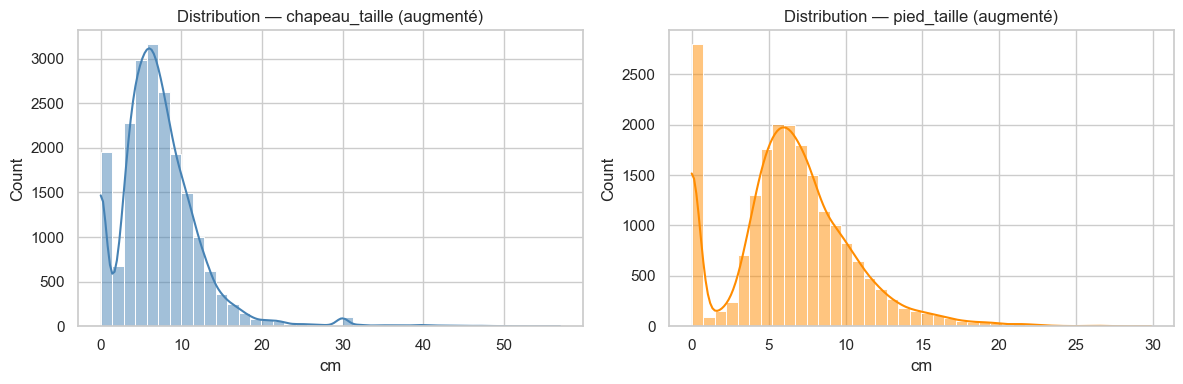

In [5]:
sample = df.sample(min(20_000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(sample["chapeau_taille"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution — chapeau_taille (augmenté)")
axes[0].set_xlabel("cm")

sns.histplot(sample["pied_taille"], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution — pied_taille (augmenté)")
axes[1].set_xlabel("cm")

plt.tight_layout()
plt.show()

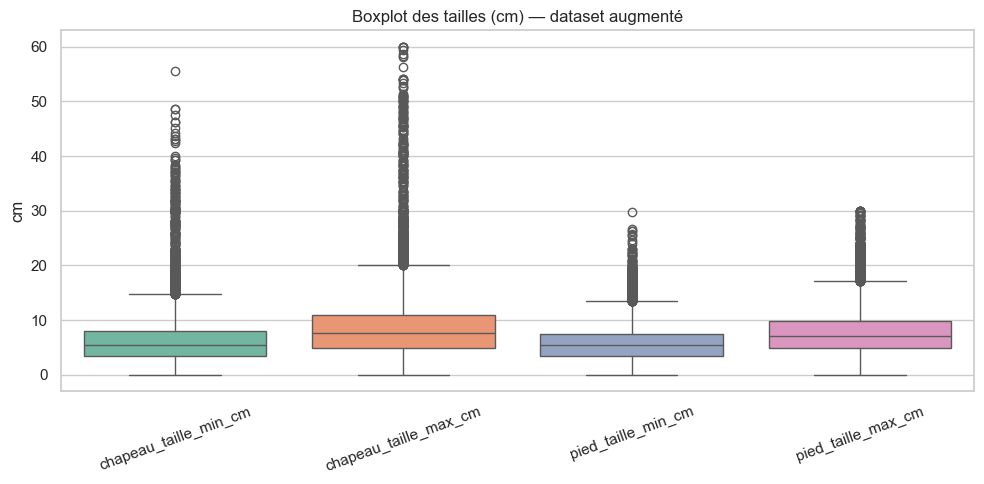

In [6]:
size_cols = ["chapeau_taille_min_cm", "chapeau_taille_max_cm", "pied_taille_min_cm", "pied_taille_max_cm"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sample[size_cols], ax=ax, palette="Set2")
ax.set_title("Boxplot des tailles (cm) — dataset augmenté")
ax.set_ylabel("cm")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3. Analyse des caractéristiques catégorielles

### 3.1 Présence des attributs (binaires)

C:\Users\benja\AppData\Local\Temp\ipykernel_1928\2336399193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")


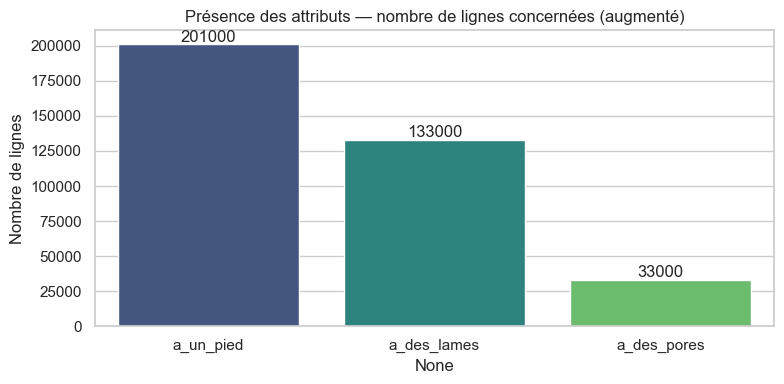

In [7]:
binary_presence = ["a_un_pied", "a_des_pores", "a_des_lames"]
counts = df[binary_presence].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
ax.set_title("Présence des attributs — nombre de lignes concernées (augmenté)")
ax.set_ylabel("Nombre de lignes")
for i, v in enumerate(counts.values):
    ax.text(i, v + (counts.max() * 0.01), f"{int(v)}", ha="center")
plt.tight_layout()
plt.show()

### 3.2 Top 10 des couleurs — chapeau et chair

C:\Users\benja\AppData\Local\Temp\ipykernel_1928\2919201950.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chapeau_top.values, y=chapeau_top.index, ax=axes[0], palette="YlOrBr")
C:\Users\benja\AppData\Local\Temp\ipykernel_1928\2919201950.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chair_top.values, y=chair_top.index, ax=axes[1], palette="PuRd")


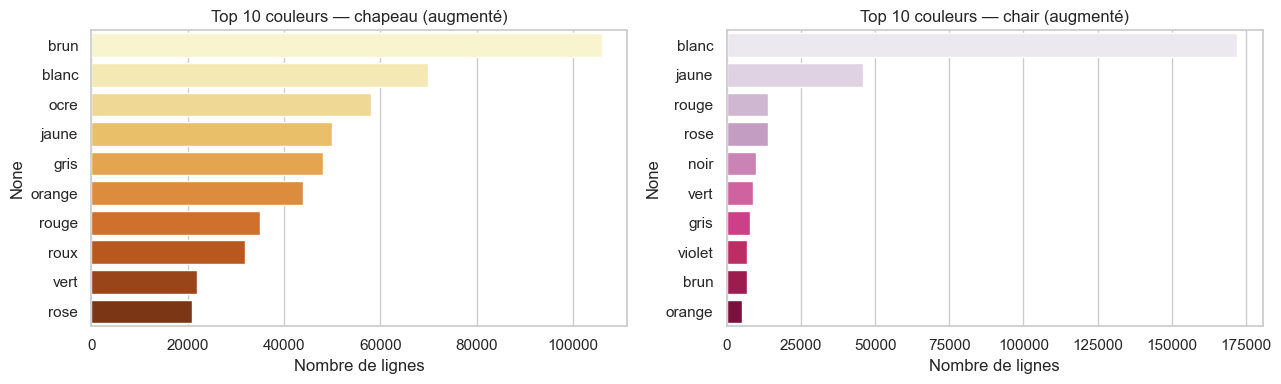

In [8]:
def top_k_by_prefix(data, prefix, k=10):
    cols = [c for c in data.columns if c.startswith(prefix)]
    counts = data[cols].sum().sort_values(ascending=False).head(k)
    counts.index = [c.replace(prefix, "") for c in counts.index]
    return counts

chapeau_top = top_k_by_prefix(df, "chapeau_couleur_", k=10)
chair_top   = top_k_by_prefix(df, "chair_couleur_",   k=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=chapeau_top.values, y=chapeau_top.index, ax=axes[0], palette="YlOrBr")
axes[0].set_title("Top 10 couleurs — chapeau (augmenté)")
axes[0].set_xlabel("Nombre de lignes")

sns.barplot(x=chair_top.values, y=chair_top.index, ax=axes[1], palette="PuRd")
axes[1].set_title("Top 10 couleurs — chair (augmenté)")
axes[1].set_xlabel("Nombre de lignes")

plt.tight_layout()
plt.show()

### 3.3 Saisons (mois d'apparition)

Rappel : l'augmentation tire **un seul mois** parmi les mois actifs de l'espèce → la somme par mois ici reflète la distribution réelle pondérée par les espèces.

C:\Users\benja\AppData\Local\Temp\ipykernel_1928\3446491889.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mois_labels, y=season_counts.values, ax=ax, palette="crest")


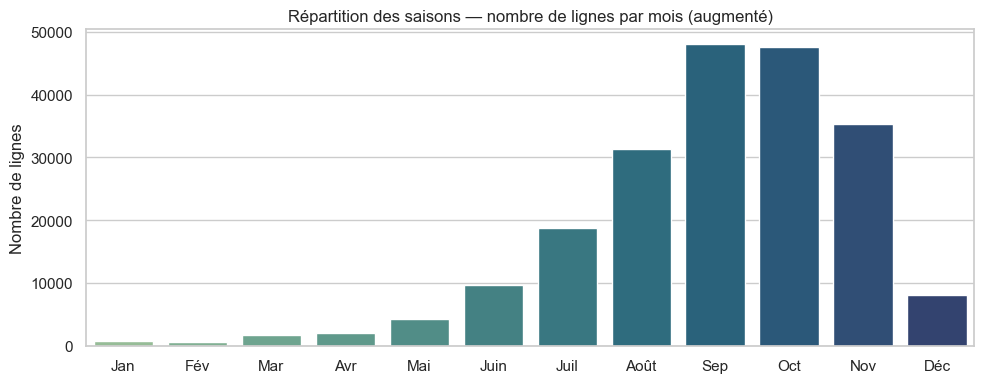

In [9]:
season_cols = [f"saison_mois_{i:02d}" for i in range(1, 13)]
season_counts = df[season_cols].sum()
mois_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=mois_labels, y=season_counts.values, ax=ax, palette="crest")
ax.set_title("Répartition des saisons — nombre de lignes par mois (augmenté)")
ax.set_ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()

### 3.4 Habitats

C:\Users\benja\AppData\Local\Temp\ipykernel_1928\1970366925.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=habitat_counts.values, y=habitat_counts.index, ax=ax, palette="mako")


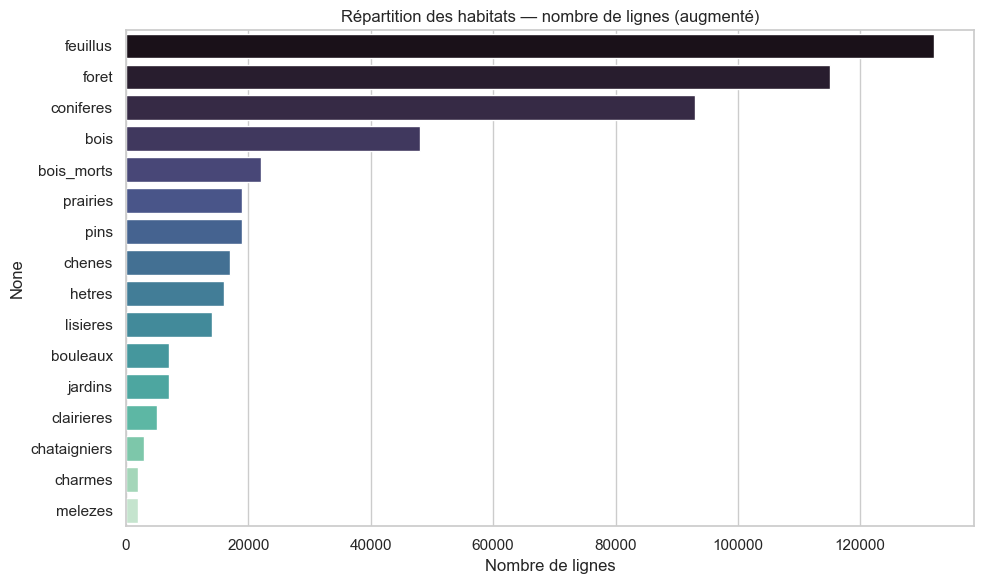

In [10]:
habitat_counts = top_k_by_prefix(df, "habitat_type_", k=16)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=habitat_counts.values, y=habitat_counts.index, ax=ax, palette="mako")
ax.set_title("Répartition des habitats — nombre de lignes (augmenté)")
ax.set_xlabel("Nombre de lignes")
plt.tight_layout()
plt.show()

## 4. Analyse de la cible

### 4.1 Cible = `nom` — vérification de l'équilibre

L'augmentation est paramétrée pour produire **N lignes par espèce** : on attend donc une répartition parfaitement équilibrée.

Nombre d'espèces distinctes : 217
Lignes par espèce — min : 1000, max : 1000, moyenne : 1000.00


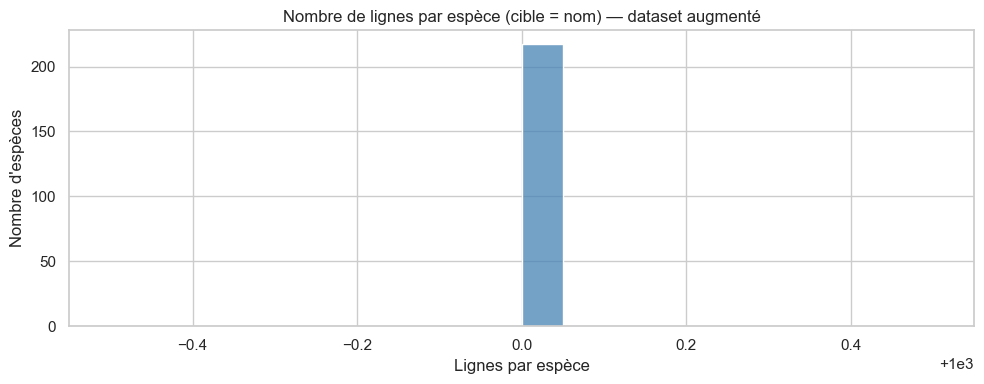

In [11]:
nom_counts = df["nom"].value_counts()
print(f"Nombre d'espèces distinctes : {nom_counts.shape[0]}")
print(f"Lignes par espèce — min : {nom_counts.min()}, max : {nom_counts.max()}, moyenne : {nom_counts.mean():.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(nom_counts.values, bins=20, ax=ax, color="steelblue")
ax.set_title("Nombre de lignes par espèce (cible = nom) — dataset augmenté")
ax.set_xlabel("Lignes par espèce")
ax.set_ylabel("Nombre d'espèces")
plt.tight_layout()
plt.show()

### 4.2 Cible = `statut`

statut
Champignon à rejeter          73000
Les bons champignons          50000
Les champignons toxiques      34000
Les champignons mediocres     33000
Les excellents champignons    18000
Les champignons mortel         9000
Name: count, dtype: int64


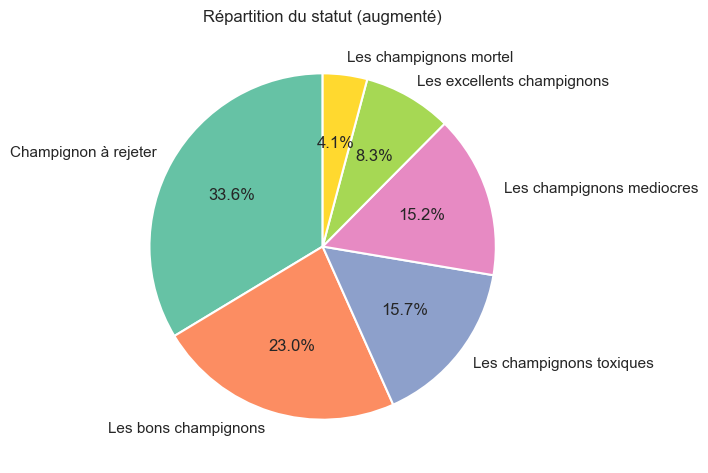

In [12]:
statut_counts = df["statut"].value_counts()
print(statut_counts)

fig, ax = plt.subplots(figsize=(7, 7))
colors = sns.color_palette("Set2", n_colors=len(statut_counts))
ax.pie(
    statut_counts.values,
    labels=statut_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Répartition du statut (augmenté)")
plt.tight_layout()
plt.show()

## 5. Comparaison synthétique vs réel

On vérifie que l'augmentation **n'a pas dérivé** des statistiques du dataset original : moyennes de tailles similaires, distribution visuellement cohérente.

### 5.1 Moyennes des tailles

In [13]:
df_clean["chapeau_taille"] = (df_clean["chapeau_taille_min_cm"] + df_clean["chapeau_taille_max_cm"]) / 2
df_clean["pied_taille"]    = (df_clean["pied_taille_min_cm"]    + df_clean["pied_taille_max_cm"])    / 2

cols = ["chapeau_taille_min_cm", "chapeau_taille_max_cm",
        "pied_taille_min_cm",    "pied_taille_max_cm",
        "chapeau_taille",        "pied_taille"]

compare = pd.DataFrame({
    "réel_mean":      df_clean[cols].mean(),
    "augmenté_mean":  df[cols].mean(),
    "réel_std":       df_clean[cols].std(),
    "augmenté_std":   df[cols].std(),
})
compare["delta_mean"] = compare["augmenté_mean"] - compare["réel_mean"]
compare["delta_pct"]  = 100 * compare["delta_mean"] / compare["réel_mean"]
compare.round(3)

C:\Users\benja\AppData\Local\Temp\ipykernel_1928\3576900825.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean["chapeau_taille"] = (df_clean["chapeau_taille_min_cm"] + df_clean["chapeau_taille_max_cm"]) / 2
C:\Users\benja\AppData\Local\Temp\ipykernel_1928\3576900825.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean["pied_taille"]    = (df_clean["pied_taille_min_cm"]    + df_clean["pied_taille_max_cm"])    / 2


,réel_mean,augmenté_mean,réel_std,augmenté_std,delta_mean,delta_pct
chapeau_taille_min_cm,2.973,6.113,2.551,4.595,3.140,105.629
chapeau_taille_max_cm,11.624,8.481,7.762,5.986,-3.143,-27.038
pied_taille_min_cm,3.189,5.554,1.930,3.554,2.365,74.165
pied_taille_max_cm,9.700,7.335,5.832,4.569,-2.365,-24.383
chapeau_taille,7.299,7.297,4.832,5.154,-0.001,-0.020
pied_taille,6.445,6.445,3.754,3.973,-0.000,-0.002


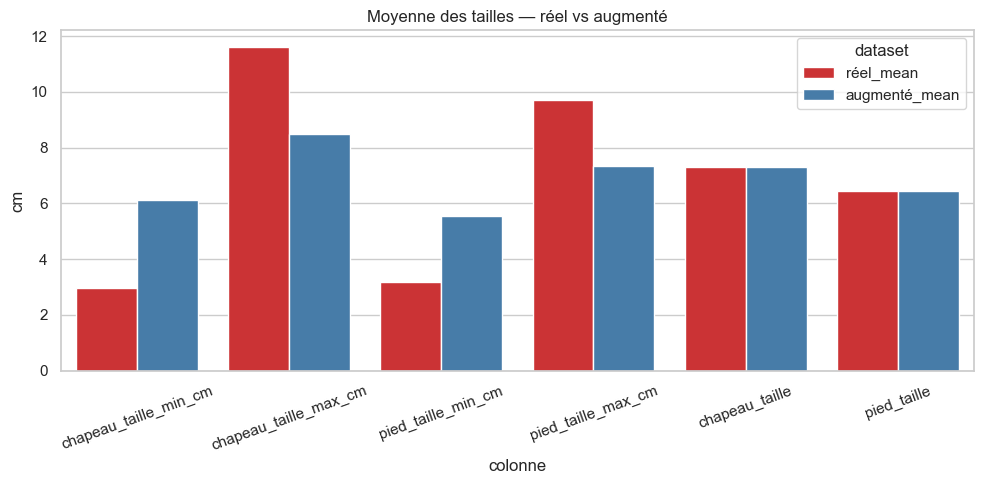

In [14]:
means_df = (
    compare[["réel_mean", "augmenté_mean"]]
    .reset_index()
    .rename(columns={"index": "colonne"})
    .melt(id_vars="colonne", var_name="dataset", value_name="moyenne")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=means_df, x="colonne", y="moyenne", hue="dataset", ax=ax, palette="Set1")
ax.set_title("Moyenne des tailles — réel vs augmenté")
ax.set_ylabel("cm")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 5.2 Distributions superposées

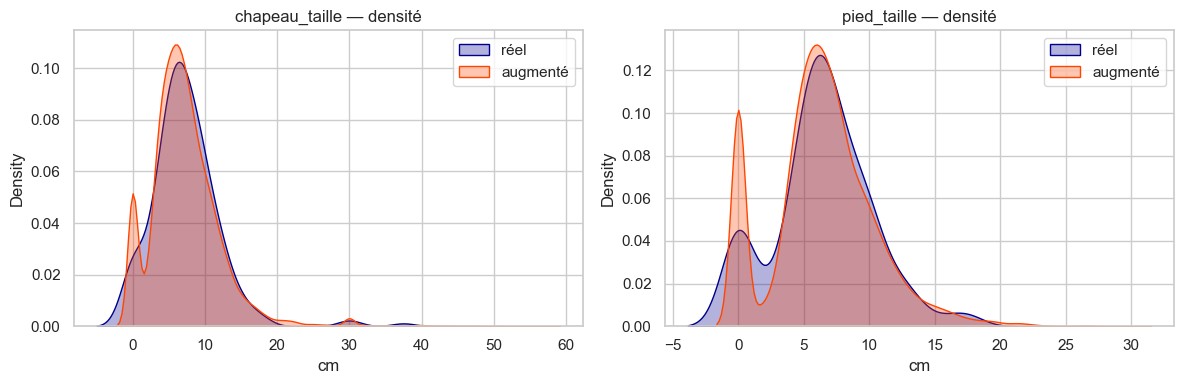

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(df_clean["chapeau_taille"].dropna(), ax=axes[0], label="réel",     color="darkblue",  fill=True, alpha=0.3)
sns.kdeplot(sample["chapeau_taille"],            ax=axes[0], label="augmenté", color="orangered", fill=True, alpha=0.3)
axes[0].set_title("chapeau_taille — densité")
axes[0].set_xlabel("cm")
axes[0].legend()

sns.kdeplot(df_clean["pied_taille"].dropna(), ax=axes[1], label="réel",     color="darkblue",  fill=True, alpha=0.3)
sns.kdeplot(sample["pied_taille"],            ax=axes[1], label="augmenté", color="orangered", fill=True, alpha=0.3)
axes[1].set_title("pied_taille — densité")
axes[1].set_xlabel("cm")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Moyenne par espèce — réel vs augmenté

Pour chaque espèce, on compare la taille moyenne sur le réel (ligne unique) et la moyenne des 1000 tirages augmentés. Les points doivent s'aligner sur la diagonale : une dérive forte signalerait un bug de l'augmentation.

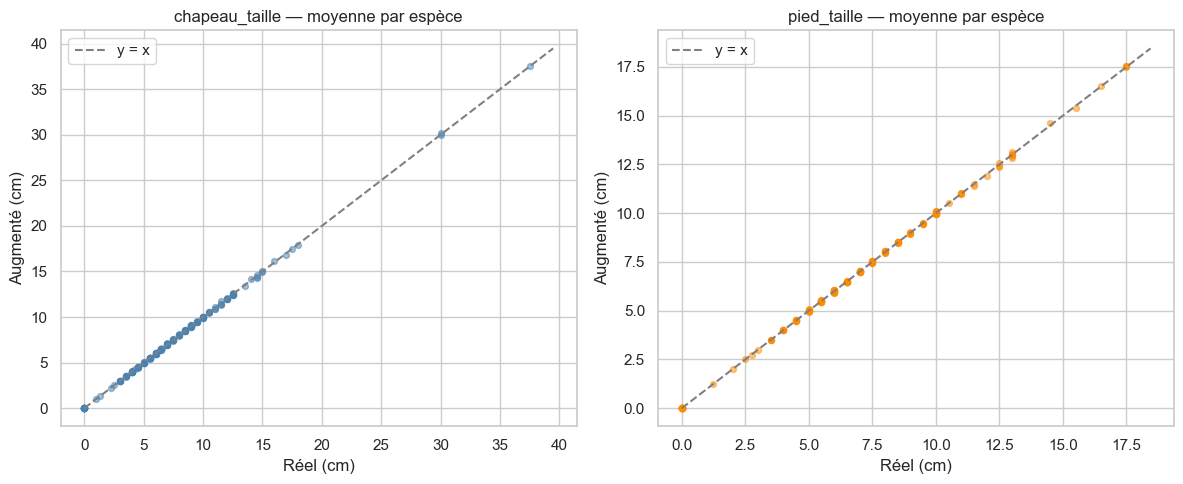

Écart moyen absolu par espèce — chapeau : 0.038 cm | pied : 0.027 cm


In [16]:
per_species = (
    df.groupby("nom")[["chapeau_taille", "pied_taille"]]
      .mean()
      .rename(columns={"chapeau_taille": "chapeau_aug", "pied_taille": "pied_aug"})
      .join(
          df_clean.set_index("nom")[["chapeau_taille", "pied_taille"]]
                  .rename(columns={"chapeau_taille": "chapeau_reel", "pied_taille": "pied_reel"})
      )
      .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(per_species["chapeau_reel"], per_species["chapeau_aug"], alpha=0.5, s=18, color="steelblue")
lim = [0, per_species[["chapeau_reel", "chapeau_aug"]].max().max() * 1.05]
axes[0].plot(lim, lim, "--", color="grey", label="y = x")
axes[0].set_xlabel("Réel (cm)")
axes[0].set_ylabel("Augmenté (cm)")
axes[0].set_title("chapeau_taille — moyenne par espèce")
axes[0].legend()

axes[1].scatter(per_species["pied_reel"], per_species["pied_aug"], alpha=0.5, s=18, color="darkorange")
lim = [0, per_species[["pied_reel", "pied_aug"]].max().max() * 1.05]
axes[1].plot(lim, lim, "--", color="grey", label="y = x")
axes[1].set_xlabel("Réel (cm)")
axes[1].set_ylabel("Augmenté (cm)")
axes[1].set_title("pied_taille — moyenne par espèce")
axes[1].legend()

plt.tight_layout()
plt.show()

delta_chapeau = (per_species["chapeau_aug"] - per_species["chapeau_reel"]).abs().mean()
delta_pied    = (per_species["pied_aug"]    - per_species["pied_reel"]).abs().mean()
print(f"Écart moyen absolu par espèce — chapeau : {delta_chapeau:.3f} cm | pied : {delta_pied:.3f} cm")